# 12_时间序列分析方法-向量自回归滑动平均

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- VARMA 增加迭代上限，只比较已经收敛的候选模型，并显式检查最终模型的收敛状态。
- VARMA 采用小型阶数候选集；失败候选显示原因。预测区间按列名读取，避免将两个变量的上下界混用；图中预测量为差分值。
- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


咱们这个小节和大家来聊聊向量自回归滑动平均（VARMA）模型\~

时间序列里的 **向量自回归滑动平均模型（VARMA）**，是把两种常见的时间序列方法结合起来的：

- **自回归（AR）**：现在的值和过去的值有关。
- **滑动平均（MA）**：现在的值还和过去的随机波动（误差项）有关。

“向量”两个字表示：我们不是只看一条时间序列，而是**同时研究多条互相关联的时间序列**。

举个例子：

假设你要预测一个国家的 **GDP** 和 **通货膨胀率**，GDP 的变化不仅和它过去的走势有关，还可能受通货膨胀率的影响。

同样，通货膨胀率的走势，也可能被 GDP 的变化带动。这时候，就不能单独研究 GDP 或单独研究通胀，而要把它们放在一个系统里一起分析。

VARMA 就是一个这样的工具：它把 “过去的数据” 和 “过去的误差” 一起考虑进去，帮助我们理解和预测这些变量的互动关系。

#### 一个小案例

想象有两个时间序列：

- $Y_t$：GDP 增长率
- $X_t$：通货膨胀率

一个简单的 VARMA 模型可能长这样：


$$
\begin{cases}Y_t = a_1 Y_{t-1} + b_1 X_{t-1} + c_1 \varepsilon_{t-1} + \varepsilon_{1t} \\X_t = a_2 X_{t-1} + b_2 Y_{t-1} + c_2 \varepsilon_{t-1} + \varepsilon_{2t}\end{cases}
$$


这里：

- $a_1, a_2, b_1, b_2$ 是自回归部分（看过去的值）
- $c_1, c_2$ 是滑动平均部分（看过去的误差）
- $\varepsilon_{1t}, \varepsilon_{2t}$ 是当前的随机扰动

其中：

- **VAR**：只考虑变量之间的过去值
- **VMA**：只考虑过去的误差
- **VARMA**：两者结合，更灵活，更贴近实际经济、金融等系统的复杂关系

用一场球赛比拟：

- 球队的表现（现在）不仅和它过去几场的状态（AR）有关
- 还可能受到裁判误判、天气等偶然因素的影响（MA）
- 如果有两支球队的成绩互相牵制，那就得用向量形式（VARMA）来一起分析。

## 原理详解

#### 模型设定（矩阵/多项式表示）

设 $\{\mathbf{y}_t\}$ 是 $k$-维向量时间序列（列向量），$\varepsilon_t$ 为 $k$-维白噪声（创新）：


$$
E[\varepsilon_t] = \mathbf{0},\qquad E[\varepsilon_t\varepsilon_s']=\begin{cases}\Sigma_\varepsilon & t=s\\[2pt]\mathbf{0} & t\ne s\end{cases}
$$


定义滞后算子 $L$ 作用为 $L\mathbf{y}_t=\mathbf{y}_{t-1}$。

VARMA($p,q$) 的矩阵多项式形式为：


$$
\Phi(L)\mathbf{y}_t = \Theta(L)\varepsilon_t,
$$


其中：

- $\Phi(L)=I_k - \Phi_1 L - \Phi_2 L^2 -\cdots - \Phi_p L^p,\qquad\Theta(L)=I_k + \Theta_1 L + \Theta_2 L^2 +\cdots + \Theta_q L^q.$

注：这里规定 $\Phi_0=I_k,\ \Theta_0=I_k$。可含常数项 $\mu$：一般写成 $\Phi(L)(\mathbf{y}_t-\mu)=\Theta(L)\varepsilon_t$。

#### 特殊情形与表述等价性

- 若 $\Theta(L)=I_k$，得到向量自回归 VAR($p$)：$\mathbf{y}_t=\sum_{i=1}^p\Phi_i\mathbf{y}_{t-i}+\varepsilon_t$。
- 若 $\Phi(L)=I_k$，得到向量移动平均 VMA($q$)：$\mathbf{y}_t=\sum_{j=0}^q\Theta_j\varepsilon_{t-j}$（$\Theta_0=I_k$）。
- 在因果且可逆的情形下，VARMA 具有 VMA($\infty$)（Wold）表示：$\mathbf{y}_t=\Psi(L)\varepsilon_t,\ \Psi(L)=\Phi(L)^{-1}\Theta(L)=\sum_{i=0}^\infty\Psi_i L^i$。

#### 因果性（稳定性）与可逆性：多项式根的条件（直观与等价条件）

- **因果性（稳定）**：要求模型能用过去的创新表示当前 $\mathbf{y}_t$（即存在 VMA($\infty$) 展开且系数衰减）。等价条件是矩阵多项式 $\det(\Phi(z))$ 在复平面单位圆域内不为 0——更常见的说法：$\det(\Phi(z))=0$ **的所有根都位于复平面单位圆之外（模大于 1）**。等价地，伴随（companion）矩阵的特征值模小于 1。
- **可逆性（invertibility）**：要求能把创新表达为观测的滞后线性组合（即存在 $\Theta(L)^{-1}$ 的展开）。等价条件为 $\det(\Theta(z))$ 的根也位于单位圆外。

要注意：这两套条件分别保证能把 $\mathbf{y}_t$ 写作 $\Psi(L)\varepsilon_t$（因果）或把 $\varepsilon_t$ 写作 $\Xi(L)\mathbf{y}_t$（可逆），其中 $\Psi,\Xi$ 是收敛的幂级数矩阵。

#### 伴随矩阵与稳定性判定（构造与等价）

将 VAR($p$) 写成伴随形式（示范，便于理解稳定性判定）：

令 $\mathbf{Y}_t=[\mathbf{y}_t';\ \mathbf{y}_{t-1}';\ \dots;\ \mathbf{y}_{t-p+1}']'$（维度 $kp$），则


$$
\mathbf{Y}_t = \mathcal{A}\,\mathbf{Y}_{t-1} + \mathcal{B}\varepsilon_t,\qquad\mathcal{A}=\begin{bmatrix}\Phi_1 & \Phi_2 & \cdots & \Phi_{p-1} & \Phi_p\\[2pt]I_k & 0 & \cdots & 0 & 0\\[2pt]0 & I_k & \cdots & 0 & 0\\\vdots & & \ddots & & \vdots\\0 & 0 & \cdots & I_k & 0\end{bmatrix}.
$$


稳定性（因果）等价于伴随矩阵 $\mathcal{A}$ 的谱半径 $\rho(\mathcal{A})<1$（即所有特征值模小于 1）。这个条件和多项式根位置是等价表述（可通过伴随矩阵的特征多项式与 $\det(\Phi(z))$ 的关系证明）。

#### Wold 展示（VMA($\infty$））与冲击响应矩阵 $\Psi_i$ 的递推推导

在因果且可逆情形，存在


$$
\mathbf{y}_t = \Psi(L)\varepsilon_t = \sum_{i=0}^{\infty}\Psi_i \varepsilon_{t-i},\qquad \Psi_0 = I_k.
$$


由 $\Phi(L)\Psi(L)=\Theta(L)$，比较幂级数系数得到对所有 $i\ge 0$ 的递推关系（设 $\Phi_0=I_k,\ \Theta_0=I_k,\ \Theta_i=0$ 当 $i>q$）：


$$
\sum_{j=0}^{\min(p,i)} \Phi_j \Psi_{i-j} = \Theta_i.
$$


等价地对 $i\ge 1$：


$$
\Psi_i = \Phi_1 \Psi_{i-1} + \Phi_2 \Psi_{i-2} + \cdots + \Phi_p \Psi_{i-p} + \Theta_i,
$$


其中对 $i>q$ 的 $\Theta_i=0$。这给出计算冲击响应矩阵 $\Psi_i$ 的明确递推（实际应用中按需截断到 $i\le H$ 来逼近）。

**意义**：$\Psi_i$ 表示在第 $t$ 时刻对 $t-i$ 时刻单位冲击（创新）产生的即时影响矩阵（冲击响应），可用于脉冲响应函数（IRF）计算与方差分解。

#### 给定参数条件下残差（创新）如何递推计算（实用公式）

从基本方程直接解出 $\varepsilon_t$ 的递推式（因为 $\Theta_0=I_k$）：


$$
\Phi(L)\mathbf{y}_t = \Theta(L)\varepsilon_t\quad\Rightarrow\quad\varepsilon_t = \mathbf{y}_t - \sum_{i=1}^p \Phi_i \mathbf{y}_{t-i} - \sum_{j=1}^q \Theta_j \varepsilon_{t-j}.
$$


这条公式是实际计算样本残差（innovation）$\hat\varepsilon_t$ 的工作公式：给定参数矩阵 $\Phi_i,\Theta_j$，从 $t=1$ 起向前递推（需对初始的 $\varepsilon_{t}$ 给定初值，常取 0 或用回溯法/填充）即可得到残差序列。

#### 极大似然估计（MLE）：似然函数与计算要点

若假定 $\varepsilon_t\stackrel{\text{i.i.d.}}{\sim}N(0,\Sigma)$，则基于样本 $t=1,\dots,T$ 的（条件）对数似然（忽略常数）为：


$$
\ell(\theta) = -\frac{T}{2}\log|\Sigma| - \frac{1}{2}\sum_{t=1}^T \varepsilon_t(\theta)'\Sigma^{-1}\varepsilon_t(\theta).
$$


其中 $\theta$ 表示所有待估参数（$\{\Phi_i\},\{\Theta_j\},\Sigma$），且 $\varepsilon_t(\theta)$ 通过上面的递推式给出（依赖参数）。

两种常用实现方式：

- **条件似然（conditional ML）**：以样本起始时刻的若干滞后值为条件（固定初始 $\varepsilon$ 或 $\mathbf{y}_{\text{init}}$），用递推式计算残差代入上式进行数值优化（常用，计算简单，渐近一致）。
- **确切似然（exact ML）**：通过把 VARMA 写为状态空间形式并用卡尔曼滤波来递推计算逐步创新分量及其协方差，从而计算精确对数似然（尤其当要处理初始条件及短样本偏差时更好）。下面给出卡尔曼滤波的标准递推式用于似然评估。

#### 状态空间表示与卡尔曼滤波（用于精确似然与预测）

VARMA 可等价地写为状态空间模型（存在一组矩阵 $T,Z,R$ 使得）：


$$
\begin{cases}\alpha_{t+1} = T \alpha_t + R \varepsilon_{t+1},\\[2pt]\mathbf{y}_t = Z \alpha_t + \varepsilon_t,\end{cases}
$$


其中 $\alpha_t$ 为状态向量（由过去的 $\mathbf{y}$ 与过去创新组成或按某种标准化选择）。 给定此形式，卡尔曼滤波的标准递推为（以已知 $\Sigma=\operatorname{Var}(\varepsilon_t)$）：

预测（predict）：


$$
\hat\alpha_{t|t-1} = T\hat\alpha_{t-1|t-1},\quad P_{t|t-1} = T P_{t-1|t-1} T' + R\Sigma R'.
$$


创新（innovation）：


$$
v_t = \mathbf{y}_t - Z\hat\alpha_{t|t-1},\quad S_t = Z P_{t|t-1} Z' + \Sigma.
$$


更新（update）：


$$
K_t = P_{t|t-1} Z' S_t^{-1},\qquad\hat\alpha_{t|t} = \hat\alpha_{t|t-1} + K_t v_t,
$$


$$
P_{t|t} = P_{t|t-1} - K_t S_t K_t'.
$$


卡尔曼滤波同时输出每一步的创新 $v_t$ 和其协方差 $S_t$。对数似然可以写成（忽略常数）：


$$
\ell(\theta) = -\frac{1}{2}\sum_{t=1}^T \left(\log|S_t| + v_t' S_t^{-1} v_t\right).
$$


在数值优化中可用此确切似然对 $\theta$ 优化；需要在参数空间上保证稳定性/可逆性（或在优化过程中对参数做重参数化以强制这些约束）。

注意：构造具体的 $T,Z,R$ 需遵循某种标准化的状态选择，文本书如 Durbin & Koopman 或 Lütkepohl 等有明确构造。关键是存在这样的等价表示，能用卡尔曼滤波高效计算似然与预测。

#### Hannan–Rissanen 三步估计算法（常用、直观且实用的逐步方法）

Hannan–Rissanen 是把 ARMA（及 VARMA）估计化为若干次 OLS 回归以得到初始值，随后用 MLE 精炼的经典程序。对 VARMA($p,q$) 的三步形式（矩阵形式）：

**步骤 1（高阶 VAR 近似）**  
选一个大的滞后阶数 $m$（例如 $m\gg p,q$），估计 VAR($m$)：


$$
\mathbf{y}_t = \sum_{i=1}^m B_i \mathbf{y}_{t-i} + u_t,
$$


使用 OLS（多元回归）得到 $\hat B_i$ 及残差 $\hat u_t$（它们近似 $\varepsilon_t$ 的线性预测）。

**步骤 2（构造回归求初值）**  
用步骤 1 的 $\hat u_t$ 代替未知的过去创新项，在下式中用 OLS 回归求 $\Phi_i,\Theta_j$ 的初始估计：


$$
\mathbf{y}_t = \sum_{i=1}^p \Phi_i \mathbf{y}_{t-i} + \sum_{j=1}^q \Theta_j \hat u_{t-j} + \text{残差}.
$$


这一回归是多变量线性回归（对每个 t，右侧把所有矩阵因子堆叠成矩阵回归），求出初始 $\hat\Phi,\hat\Theta$。

**步骤 3（非线性最优化—MLE 精化）**  
以步骤 2 的初值作为初始点，使用数值优化（例如 BFGS、牛顿或其他）最大化真实或近似对数似然（使用卡尔曼滤波计算确切似然或使用条件似然）。步骤 3 给出最终估计与标准误。

**数学要点**：步骤 2 的 OLS 解通过最小平方矩阵方程给出（用样本矩阵 $X$ 与 $Y$），步骤 3 的优化则需计算似然并可能计算梯度（可用数值近似或利用卡尔曼滤波的灵敏度方程）。

#### 频域方法：谱密度与 Whittle 估计（替代思路）

VARMA 的谱密度矩阵为（频率 $\omega\in[-\pi,\pi]$）：


$$
f_y(\omega) = \frac{1}{2\pi}\,\Psi(e^{-i\omega})\,\Sigma_\varepsilon\,\Psi(e^{-i\omega})',\qquad\Psi(e^{-i\omega})=\Phi(e^{-i\omega})^{-1}\Theta(e^{-i\omega}).
$$


基于周期图的 Whittle 近似似然可以用于大样本情况下的估计，目标是最小化（频域上）关于 $f_y(\omega;\theta)$ 的某个积分近似项。频域法在大样本和计算上常比时域 MLE 更快，但对小样本和非高斯噪声不一定优。

#### 参数识别（可辨识性）与规范化问题

VARMA 的一个重要理论问题是：不同的多项式对 $(\Phi,\Theta)$ 可能导致相同的传递函数 $\Psi(L)=\Phi(L)^{-1}\Theta(L)$。

例如，如果存在矩阵多项式 $C(L)$ 可左右因子化，使得 $\Phi(L)=\tilde\Phi(L)C(L),\ \Theta(L)=\tilde\Theta(L)C(L)$，则 $\Phi^{-1}\Theta=\tilde\Phi^{-1}\tilde\Theta$，参数非唯一。

为了解决这类问题，通常假定：

$\Phi$ 与 $\Theta$ 在多项式域上是**互质（coprime）**的（没有公共因子）；

- 采用标准化条件例如 $\Theta_0=I_k$；或者在估计中限制某些系数结构（可栏限制）以保证唯一化。

若不满足这类规范化，MLE 可能识别不到唯一参数。

#### 预测（h 步）与预测误差协方差的精确表达

在因果表示下（$\mathbf{y}_t=\sum_{i=0}^\infty\Psi_i\varepsilon_{t-i}$），给出 $h$-步预报与误差协方差：

**点预测（基于时刻** $t$ **的信息）**：  
$\hat{\mathbf{y}}_{t+h|t} = \sum_{j=0}^{\infty} \Psi_{j+h}\varepsilon_{t-j} = \sum_{m=1}^p \Phi_m \hat{\mathbf{y}}_{t+h-m|t}\ \ (\text{递归计算亦可})$

实务上用有限项近似或递归 AR 形式计算预测值；对于 MA 成分，未来创新设为零。

**预测误差协方差（h 步）**：


$$
\mathrm{Var}(\mathbf{y}_{t+h}-\hat{\mathbf{y}}_{t+h|t}) = \Omega_h=\sum_{i=0}^{h-1}\Psi_i\Sigma_\varepsilon\Psi_i'.
$$


特别地，$h=1$ 时 $\Omega_1=\Psi_0\Sigma\Psi_0'=\Sigma$。

#### 脉冲响应（IRF）与预测误差方差分解（FEVD）

- **IRF**：第 $i$ 期冲击对当前/未来变量的影响由 $\Psi_i$ 给出。常检视 $\Psi_i$ 的元素（或对冲击进行正交化，例如 Cholesky 分解）来得到结构化冲击影响。
- **方差分解**：第 $h$ 步预测误差方差中由第 $j$ 个冲击贡献的比重可写成（若对冲击已正交化）：


$$
\text{Contribution}_{j}(h) = \frac{\sum_{i=0}^{h-1} ( \text{col}_j(\Psi_i) )' \Sigma_\varepsilon \, ( \text{col}_j(\Psi_i) )}{\operatorname{trace}(\Omega_h)}
$$


或按变量逐元素计算分解比例（具体正交化方法会影响具体数值：例如 Cholesky、创新逼近或结构化识别下的冲击分解）。

#### 诊断检验与模型选择

- **信息准则**：多变量 AIC / BIC：


$$
\text{AIC} = -2\ell(\hat\theta) + 2\,\#\text{parameters},\qquad\text{BIC} = -2\ell(\hat\theta) + \log(T)\,\#\text{parameters}.
$$


参数个数包括 $\Phi_i$ 与 $\Theta_j$ 中的独立元素以及 $\Sigma_\varepsilon$ 的 $k(k+1)/2$ 个元素。

- **残差白噪声检验**：用多元扩展的端点统计（multivariate Portmanteau tests，如 Hosking 的检验或 Li–McLeod 的多元版本），检查 $\hat\varepsilon_t$ 的自相关矩阵是否显著。也可检查 $\hat\varepsilon_t$ 的正态性、均值为 0、协方差稳健性等。
- **稳定性检验**：检验估计的伴随矩阵特征值是否都在单位圆内，检验 $\Phi(L)$ 的根位置。

#### 渐近性与推断

在常见的正则条件与辨识条件下，MLE（或某些一致的估计方法）是**一致**且**渐近正态**的：


$$
\sqrt{T}(\hat\theta-\theta_0)\ \xrightarrow{d}\ N(0,\; I(\theta_0)^{-1}),
$$


其中 $I(\theta_0)$ 为费舍尔信息矩阵（可由对数似然二阶矩极限获得）。实际中可用观测信息矩阵（负 Hessian）或自举法估计标准误。

### 完整算法流程

下面是一个从数据到最终模型与诊断的细化流程（每步包含关键公式或操作要点）：

#### 1. 数据准备与前检

- 检查并（必要时）去趋势、去均值，或加入截距项 $\mu$。
- 单位根与协整检验（若存在 I(1) 变量，VARMA 要慎用，通常转为 VECM/VARIMA 框架）。

#### 2. 确定滞后阶数 p,q 的初步选择

- 可用信息准则（以近似方法：例如先拟合高阶 VAR，利用 AIC/BIC 选 p），也可用交叉验证或经济直觉。
- 常用策略：先拟合 VAR($m$)（$m$ 较大），观察部分自相关矩阵 / Akaike 指标等以收敛为准。

#### 3. 初始估计（Hannan–Rissanen）

- 步骤 1：估计 VAR($m$)，得残差 $\hat u_t$。
- 步骤 2：回归求 OLS 初值：$\mathbf{y}_t$ 对 $\{\mathbf{y}_{t-i}\}_{i=1}^p$ 与 $\{\hat u_{t-j}\}_{j=1}^q$ 回归。
- 得到 $\hat\Phi^{(0)},\hat\Theta^{(0)}$, 并估 $\hat\Sigma^{(0)}$。

#### 4. 精确估计（MLE via 卡尔曼滤波）

- 将 VARMA 转为状态空间（选择合适 $\alpha_t,T,Z,R$），用卡尔曼滤波计算似然增量 $v_t,S_t$，汇总得到确切对数似然 $\ell(\theta)$。
- 用数值优化器最大化 $\ell(\theta)$（参数约束：保证稳定性/可逆性，或使用 reparametrization 技巧）。
- 输出 $\hat\theta$ 和估计协方差（用负 Hessian 或近似 Fisher 信息）。

#### 5. 诊断与修正

- 检查残差的自相关（多元 portmanteau）、正态性、异方差等。
- 检验伴随矩阵谱半径（稳定性）。
- 若不满足，改模型（改变 p,q，或加结构/约束）。

#### 6. 结果分析：IRF、FEVD、预测

- 通过 $\Psi_i$ 递推计算冲击响应（截断到合适滞后 H）。
- 计算 $h$-步预测与预测误差协方差 $\Omega_h$。
- 做脉冲响应图、方差分解表与预测区间。

#### 7. 报告与不确定性评估

- 给出系数估计、标准误、信息准则值、残差性检验 p 值、预测区间与 IRF 的置信区间（可用基于参数估计的 delta 法或自举）。

总的来说，VARMA 是把向量自回归（AR）与向量滑动平均（MA）结合的模型，能同时考虑变量间滞后内生影响与过去随机冲击的影响。

理论核心在于矩阵多项式 $\Phi(L),\Theta(L)$ 的因果性/可逆性条件（根的位置）和由此得到的 VMA($\infty$) 展开（冲击响应 $\Psi_i$），许多推断与预测建立在这些展开与卡尔曼滤波能否稳定计算之上。

估计上常用 Hannan–Rissanen 给初值，最终用状态空间 + 卡尔曼滤波进行 MLE，这样既实用又能处理初始条件与短期动态。

实际使用时注意参数可辨识性、样本量、稳定性约束以及非平稳/协整问题。

## 完整案例

在宏观经济分析中，消费者物价指数（CPI）和利率是两个重要指标。

CPI反映通货膨胀水平，而利率政策直接影响经济活动。

研究二者之间的动态关系，有助于预测通货膨胀趋势和政策效果。

**目标：**

利用**VARMA（向量自回归滑动平均）模型**分析CPI与利率的联动关系，进行预测并可视化展示。

**技术路线：**

1. 数据准备与可视化
2. 平稳性检验
3. VARMA模型拟合
4. 模型诊断与优化
5. 预测及可视化
6. 总结与分析

**完整代码**：

/var/folders/q6/v6bs8gb12gd1lh35j2b7z3sc0000gn/T/ipykernel_11704/3052701120.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2000-01-01', periods=240, freq='M')


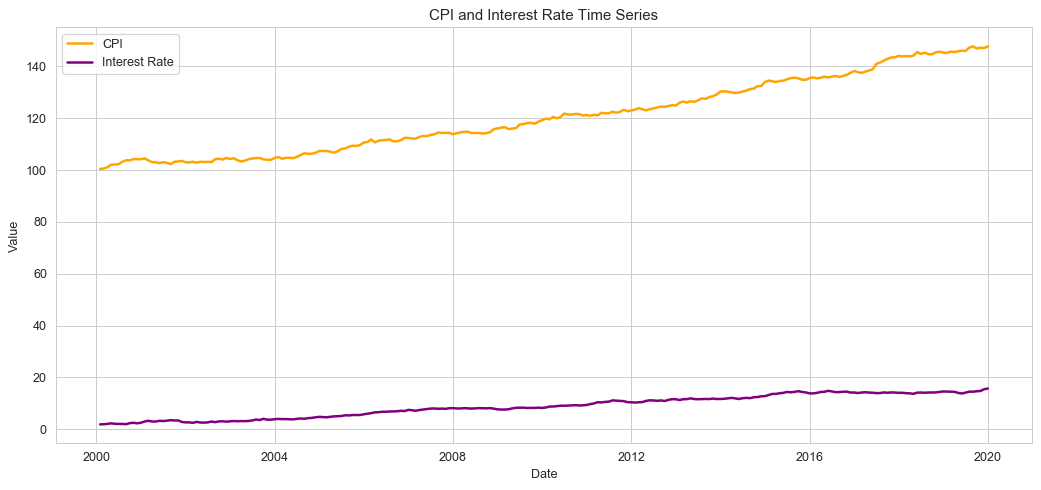

ADF Statistic for CPI: 1.2582
p-value: 0.9964
Critical Value 1%: -3.4580
Critical Value 5%: -2.8737
Critical Value 10%: -2.5733
---
ADF Statistic for Interest Rate: -0.4200
p-value: 0.9067
Critical Value 1%: -3.4580
Critical Value 5%: -2.8737
Critical Value 10%: -2.5733
---


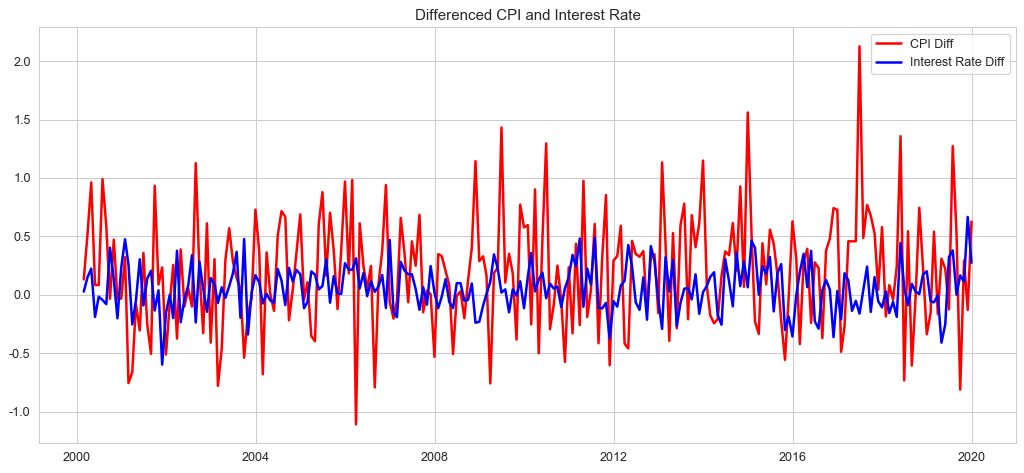

In [2]:
# 1. 所需Python库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.graphics.tsaplots import plot_acf

sns.set_style("whitegrid")

plt.rcParams['font.sans-serif'] = CJK_FONTS
plt.rcParams["figure.figsize"] = (12, 6)

# 2. 数据准备（模拟示例）
np.random.seed(42)
dates = pd.date_range(start='2000-01-01', periods=240, freq='M')
cpi = np.cumsum(np.random.normal(0.2, 0.5, 240)) + 100
interest_rate = np.cumsum(np.random.normal(0.05, 0.2, 240)) + 2

data = pd.DataFrame({"CPI": cpi, "InterestRate": interest_rate}, index=dates)

# 3. 数据可视化
plt.figure(figsize=(14,6))
plt.plot(data.index, data['CPI'], label='CPI', color='orange', linewidth=2)
plt.plot(data.index, data['InterestRate'], label='Interest Rate', color='purple', linewidth=2)
plt.title('CPI and Interest Rate Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.show()

# 4. 平稳性检验
def adf_test(series, name=''):
    result = adfuller(series)
    print(f'ADF Statistic for {name}: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    for key, value in result[4].items():
        print(f'Critical Value {key}: {value:.4f}')
    print('---')

adf_test(data['CPI'], 'CPI')
adf_test(data['InterestRate'], 'Interest Rate')

# 一阶差分处理
data_diff = data.diff().dropna()
plt.figure(figsize=(14,6))
plt.plot(data_diff.index, data_diff['CPI'], label='CPI Diff', color='red', linewidth=2)
plt.plot(data_diff.index, data_diff['InterestRate'], label='Interest Rate Diff', color='blue', linewidth=2)
plt.title('Differenced CPI and Interest Rate')
plt.legend()
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


Best VARMA order by AIC: (1, 1), AIC=248.80


/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/varmax.py:160: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


                              Statespace Model Results                             
Dep. Variable:     ['CPI', 'InterestRate']   No. Observations:                  239
Model:                          VARMA(1,1)   Log Likelihood                -111.402
                               + intercept   AIC                            248.803
Date:                     Sat, 12 Sep 2026   BIC                            293.997
Time:                             14:43:40   HQIC                           267.015
Sample:                         02-29-2000                                         
                              - 12-31-2019                                         
Covariance Type:                       opg                                         
Ljung-Box (L1) (Q):             0.11, 0.26   Jarque-Bera (JB):           9.95, 0.07
Prob(Q):                        0.74, 0.61   Prob(JB):                   0.01, 0.97
Heteroskedasticity (H):         1.15, 1.19   Skew:                      0.35

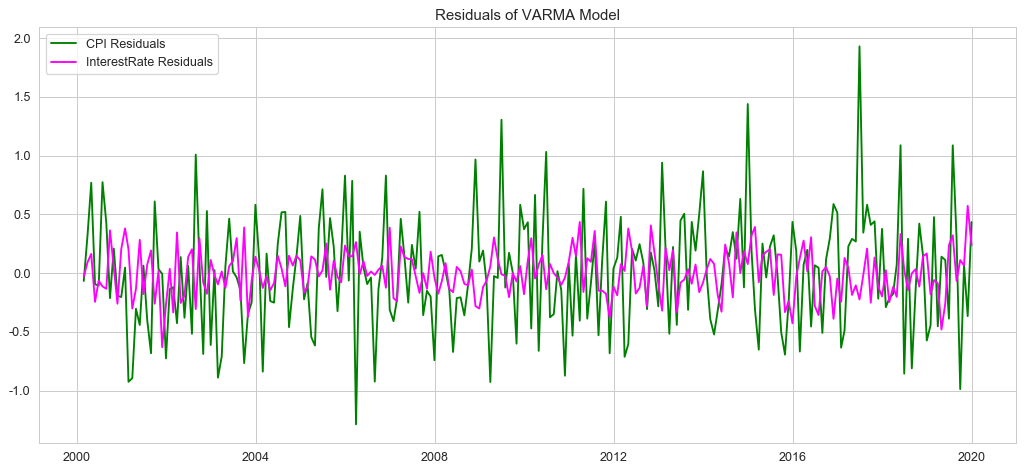

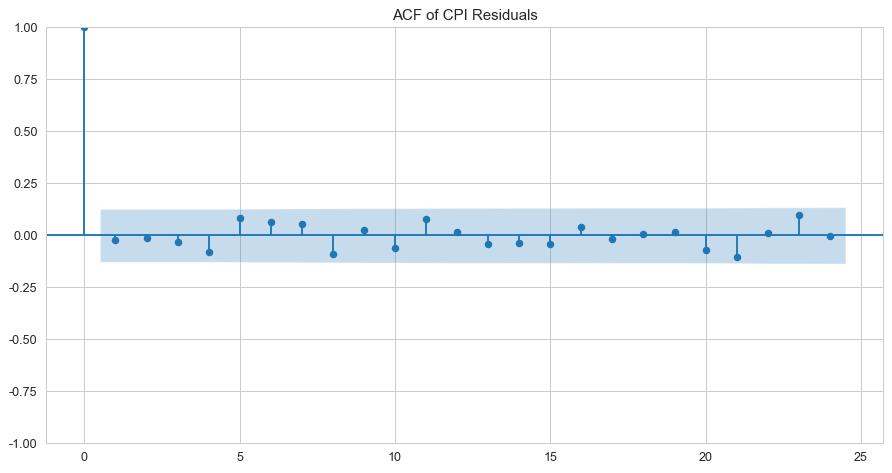

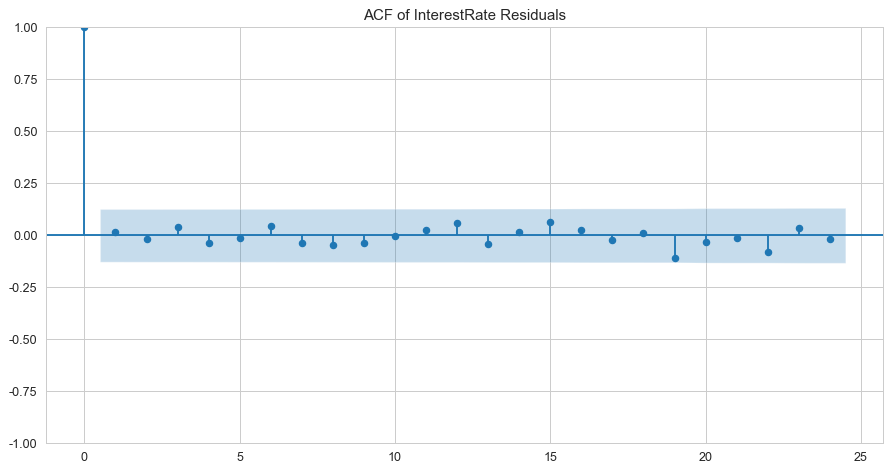

Forecast CI columns: Index(['lower CPI', 'lower InterestRate', 'upper CPI', 'upper InterestRate'], dtype='object')


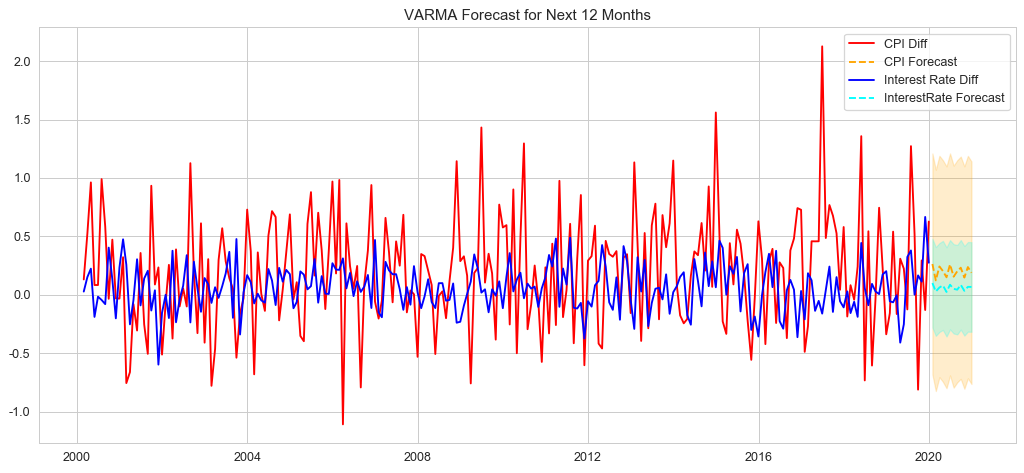

In [3]:
# 5. VARMA模型阶数选择
best_aic = np.inf
best_order = None
for p in range(1,3):
    for q in [1]:
        try:
            model = VARMAX(data_diff, order=(p,q))
            results = model.fit(disp=False, maxiter=500)
            if results.mle_retvals.get('converged', False) and np.isfinite(results.aic) and results.aic < best_aic:
                best_aic = results.aic
                best_order = (p,q)
        except (ValueError, np.linalg.LinAlgError) as exc:
            print(f'Candidate {(p,q)} failed: {exc}')

assert best_order is not None, '没有收敛的候选模型，请检查数据和阶数。'
print(f'Best VARMA order by AIC: {best_order}, AIC={best_aic:.2f}')

# 6. 模型拟合
model = VARMAX(data_diff, order=best_order)
results = model.fit(disp=False, maxiter=500)
assert results.mle_retvals.get('converged', False), '最终模型未收敛。'
print(results.summary())

# 7. 模型诊断
residuals = results.resid
plt.figure(figsize=(14,6))
plt.plot(residuals.index, residuals['CPI'], label='CPI Residuals', color='green', linewidth=1.5)
plt.plot(residuals.index, residuals['InterestRate'], label='InterestRate Residuals', color='magenta', linewidth=1.5)
plt.title('Residuals of VARMA Model')
plt.legend()
plt.show()

# ACF检验残差
plot_acf(residuals['CPI'], lags=24, title='ACF of CPI Residuals')
plt.show()
plot_acf(residuals['InterestRate'], lags=24, title='ACF of InterestRate Residuals')
plt.show()

# 8. 预测与可视化
# 预测未来12期
forecast = results.get_forecast(steps=12)

# 获取预测均值
forecast_mean = forecast.predicted_mean

# 获取置信区间
forecast_ci = forecast.conf_int()

# 查看列名，确保索引正确
print("Forecast CI columns:", forecast_ci.columns)

plt.figure(figsize=(14,6))

# CPI预测
plt.plot(data_diff.index, data_diff['CPI'], label='CPI Diff', color='red')
plt.plot(forecast_mean.index, forecast_mean['CPI'], label='CPI Forecast', color='orange', linestyle='--')

# CPI置信区间
cpi_lower = forecast_ci['lower CPI']
cpi_upper = forecast_ci['upper CPI']
plt.fill_between(forecast_mean.index, cpi_lower, cpi_upper, color='orange', alpha=0.2)

# 利率预测
plt.plot(data_diff.index, data_diff['InterestRate'], label='Interest Rate Diff', color='blue')
plt.plot(forecast_mean.index, forecast_mean['InterestRate'], label='InterestRate Forecast', color='cyan', linestyle='--')

# 利率置信区间
ir_lower = forecast_ci['lower InterestRate']
ir_upper = forecast_ci['upper InterestRate']
plt.fill_between(forecast_mean.index, ir_lower, ir_upper, color='cyan', alpha=0.2)

plt.title('VARMA Forecast for Next 12 Months')
plt.legend()
plt.show()

1. **导入库**

   - `pandas`、`numpy`处理数据；
   - `matplotlib`、`seaborn`进行可视化；
   - `statsmodels`提供VARMAX建模、ADF检验、ACF分析。
2. **数据准备**

   - 模拟CPI和利率时间序列；
   - 构建DataFrame并设置日期索引。
3. **数据可视化**

   - 绘制原始序列趋势图；
   - 观察波动和趋势，为建模提供直观理解。
4. **平稳性检验**

   - 使用ADF检验判断序列是否平稳；
   - 非平稳序列进行一阶差分，满足VARMA建模要求。
5. **VARMA模型阶数选择**

   - 遍历p和q的组合，计算AIC选择最优阶数；
   - AIC值越小表示模型拟合越好。
6. **模型拟合**

   - 根据最佳阶数拟合VARMA模型；
   - 输出模型参数和显著性分析。
7. **模型诊断**

   - 绘制残差图，检查是否接近白噪声；
   - 使用ACF分析残差自相关性。
8. **预测与可视化**

   - 预测未来12个月差分序列；
   - 绘制预测曲线及置信区间，解决KeyError问题。

### 数据分析及可视化

1. **原始数据趋势**：CPI稳步上升，利率波动幅度较小，初步可见二者可能存在滞后联动。

![原文参考图，当前结果见代码输出](attachments/img_006.png)

1. **差分序列**：差分后序列中心化，更适合VARMA建模，可视化差分序列观察波动模式。

![原文参考图，当前结果见代码输出](attachments/img_007.png)

1. **残差分析**：残差近似零均值，无明显自相关，模型拟合合理，ACF图确认残差独立性，预测可靠。

![原文参考图，当前结果见代码输出](attachments/img_008.png)

1. **预测可视化**：虚线为预测均值，阴影为置信区间，CPI与利率未来变化趋势清晰可见，可直观看到预测不确定性范围。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

VARMA模型适用于多变量时间序列，同时考虑自回归和滑动平均效，捕捉变量间动态关系。

模型能拟合CPI和利率差分序列，预测结果包含置信区间，直观展示不确定性。

**优化方面**，阶数选择可更精细，使用更广泛的网格搜索，可以加入季节性或外生变量提高预测精度，残差若存在自相关，可尝试VARMAX的其他协方差选项。

**结论：**通过VARMA建模，可以系统分析CPI与利率的联动关系，并进行未来趋势预测，为经济决策提供量化依据。

## 模型分析

### VARMA 优缺点

**优点：**

1. **多变量建模能力强**：VARMA 可以同时处理多个时间序列，捕捉它们之间的相互依赖和动态关系。
2. **兼顾自回归与移动平均特性**：相比单纯的 VAR 模型，VARMA 同时考虑了历史值（AR）和残差（MA）对未来值的影响，建模更灵活，预测精度可能更高。
3. **理论基础扎实**：VARMA 模型在经济学、金融学等领域有成熟理论支持，便于解释变量之间的因果关系。
4. **可用于冲击响应分析**：通过脉冲响应函数（Impulse Response Function）可以分析某一变量变化对其他变量的动态影响。

**缺点：**

1. **模型识别复杂**：需要同时确定 AR 和 MA 阶数（p、q），以及模型稳定性和可逆性条件，参数选择复杂且计算量大。
2. **参数估计困难**：尤其在变量多、样本量有限时，参数估计可能不稳定或不可识别。
3. **对非平稳数据敏感**：VARMA 假设时间序列平稳，如果序列存在趋势或季节性，需要先进行差分或季节调整。
4. **高维数据不友好**：当变量数量增加时，参数数量呈指数级增长，可能导致过拟合和计算压力。

### 与相似算法对比

| 模型 | 主要特性 | 优势 | 劣势 | 适用场景 |
|-|-|-|-|-|
| VAR | 多变量自回归模型 | 参数较少，建模简单 | 无 MA 成分，可能忽略残差相关性 | 多变量平稳序列，残差无明显自相关 |
| ARIMA | 单变量 ARMA 模型，可差分 | 单变量建模成熟，适合非平稳序列 | 无法建模多变量相互关系 | 单变量预测，数据非平稳 |
| VARMA | 多变量 ARMA 模型 | 同时建模多变量间依赖及残差影响 | 参数估计复杂，对样本量敏感 | 多变量平稳序列，有残差相关性 |
| VECM（向量误差修正模型） | 处理协整序列 | 可建模长期均衡关系 | 仅适用于存在协整的序列 | 多变量非平稳但协整序列 |
| LSTM（深度学习） | 捕捉非线性依赖 | 可处理非线性、长记忆 | 需要大量数据，解释性差 | 非线性复杂时间序列预测 |

### 应用场景分析

**VARMA 是优选的情况：**

- 多变量时间序列间存在动态依赖且数据平稳。
- 需要同时考虑自回归和移动平均特性，以提高短期预测精度。
- 研究中关注变量间的冲击响应和动态因果关系。
- 样本量足够大，能支撑复杂模型参数估计。

**可以考虑其他算法的情况：**

- **高维或样本量有限**：VARMA 参数过多，可考虑稀疏 VAR 或 LASSO VAR，甚至深度学习模型（如 LSTM）。
- **非平稳或存在协整关系**：VECM 更适合捕捉长期均衡关系。
- **非线性强或噪声复杂**：VARMA 假设线性，非线性问题可尝试 LSTM、GRU 等深度学习方法。
- **单变量预测**：ARIMA 更简单且易解释。

时间序列的 **向量自回归滑动平均模型（VARMA）** 能够同时捕捉多变量之间的动态关系和短期冲击效应，在经济和金融系统分析中具有很强的解释力。

它的优势在于建模能力强、解释性好，但也存在参数庞大、估计复杂等不足。

因此，当数据是平稳的多变量系统且需要研究变量间联动时，VARMA 是优选；若关注预测精度或变量过多，则可以考虑 VAR、VECM 或机器学习方法。